In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
diwali=pd.read_csv('diwali.csv',encoding='latin1')
diwali.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
diwali.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [5]:
print(diwali.isnull().sum())

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64


In [6]:
diwali.drop_duplicates(inplace=True)

In [7]:
diwali

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [8]:
diwali['Amount'].sum()

np.float64(106178828.43)

In [9]:
diwali['Amount'].mean()

np.float64(9454.084981746952)

In [10]:
diwali['Amount'].max()

23952.0

In [14]:
#revenue by gender
d1=diwali.groupby('Gender')['Amount'].sum().sort_values(ascending=False)
d1

Gender
F    74307682.43
M    31871146.00
Name: Amount, dtype: float64

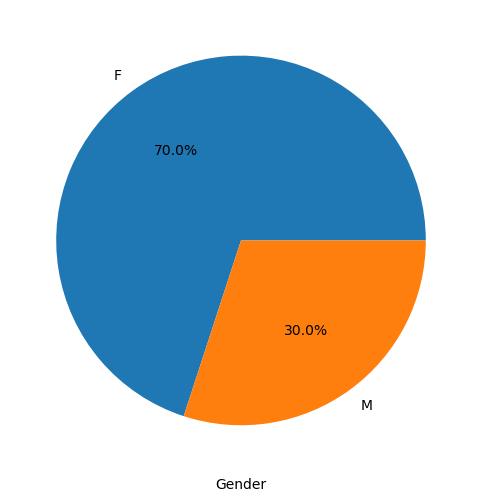

In [17]:
plt.figure(figsize=(6,6))
plt.pie(d1.values,labels=d1.index,autopct='%1.1f%%')
plt.xlabel('Gender')
plt.show()

In [19]:
#revenue by age group
d2=diwali.groupby('Age Group')['Amount'].sum().sort_values(ascending=False)
d2

Age Group
26-35    42581768.94
36-45    22135136.49
18-25    17235530.00
46-50     9207844.00
51-55     8237909.00
55+       4080987.00
0-17      2699653.00
Name: Amount, dtype: float64

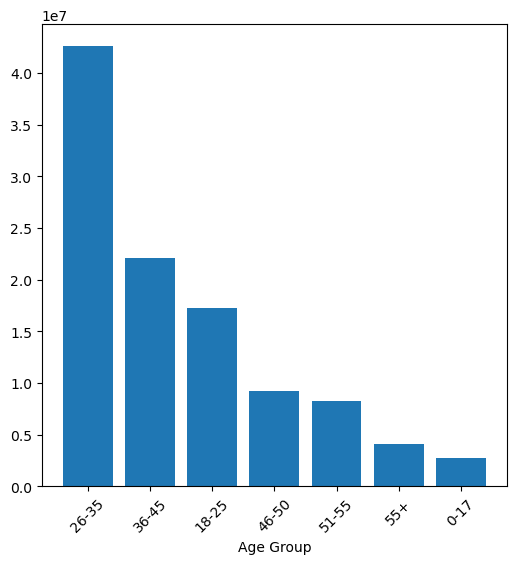

In [21]:
plt.figure(figsize=(6,6))
plt.bar(d2.index,d2.values)
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

In [23]:
#revenue by marital status
d3=diwali.groupby('Marital_Status')['Amount'].sum().sort_values(ascending=False)
d3

Marital_Status
0    62098736.44
1    44080091.99
Name: Amount, dtype: float64

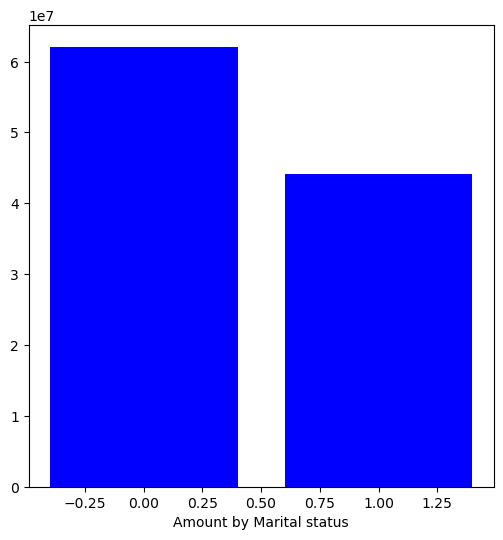

In [27]:
plt.figure(figsize=(6,6))
plt.bar(d3.index,d3.values,color='blue')
plt.xlabel('Amount by Marital status')
plt.show()

In [28]:
#revenue by state
d4=diwali.groupby('State')['Amount'].sum().sort_values(ascending=False)
d4

State
Uttar Pradesh       19346055.00
Maharashtra         14404467.00
Karnataka           13523540.00
Delhi               11603819.45
Madhya Pradesh       8101142.00
Andhra Pradesh       8037146.99
Himachal Pradesh     4963368.00
Haryana              4217871.00
Bihar                4014669.00
Gujarat              3938159.00
Kerala               3894491.99
Jharkhand            3026456.00
Uttarakhand          2520944.00
Rajasthan            1909409.00
Punjab               1525800.00
Telangana            1151490.00
Name: Amount, dtype: float64

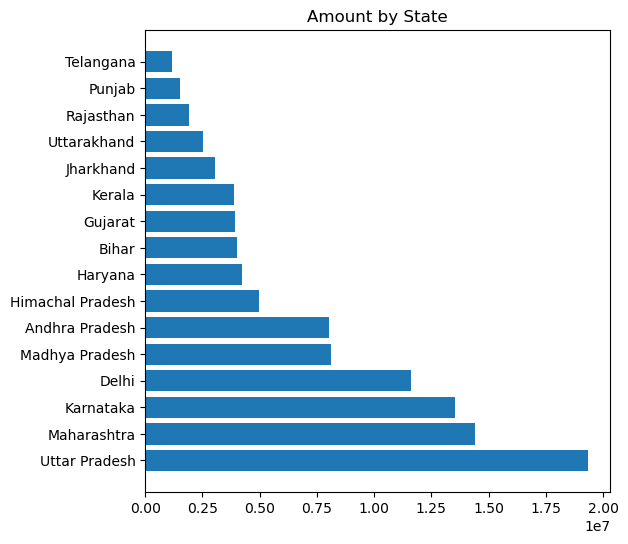

In [29]:
plt.figure(figsize=(6,6))
plt.barh(d4.index,d4.values)
plt.title('Amount by State')
plt.show()

In [31]:
d5=diwali.groupby('Zone')['Amount'].sum().sort_values(ascending=False)
d5

Zone
Central     41571960.45
Southern    26606668.98
Western     18342626.00
Northern    12616448.00
Eastern      7041125.00
Name: Amount, dtype: float64

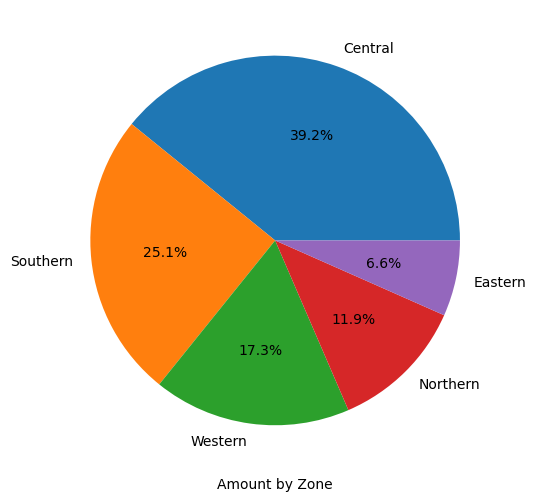

In [34]:
plt.figure(figsize=(6,6))
plt.pie(d5.values,labels=d5.index,autopct='%1.1f%%')
plt.xlabel('Amount by Zone')
plt.show()

In [71]:
#top 10 categories by amount
d11=diwali.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)
d11

Product_Category
Food                     33933883.50
Clothing & Apparel       16484472.00
Electronics & Gadgets    15607657.00
Footwear & Shoes         15575209.45
Furniture                 5440051.99
Games & Toys              4331694.00
Sports Products           3635933.00
Beauty                    1959484.00
Auto                      1935041.99
Stationery                1676051.50
Household items           1569337.00
Tupperware                1155642.00
Books                     1061478.00
Decor                      730360.00
Pet Care                   482277.00
Hand & Power Tools         405618.00
Veterinary                 112702.00
Office                      81936.00
Name: Amount, dtype: float64

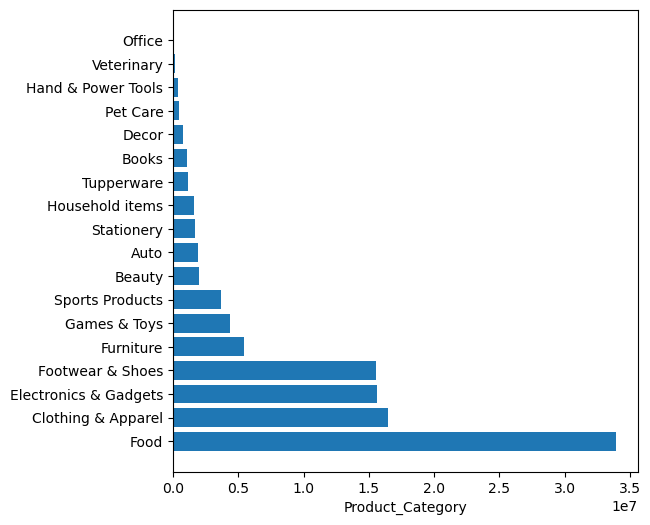

In [73]:
plt.figure(figsize=(6,6))
plt.barh(d11.index,d11.values)
plt.xlabel('Product_Category')
plt.show()

In [69]:
#top 10 customer by amount spent
d7=diwali.groupby('Cust_name')['Amount'].sum().sort_values(ascending=False).head(10)
d7

Cust_name
Vishakha     382782.0
Sudevi       287142.0
Vasudev      281034.0
Neola        275234.0
Alejandro    272517.0
Aastha       266961.0
Shreyshi     265603.0
Hazel        242343.0
Akshat       241349.0
Gopal        239147.0
Name: Amount, dtype: float64

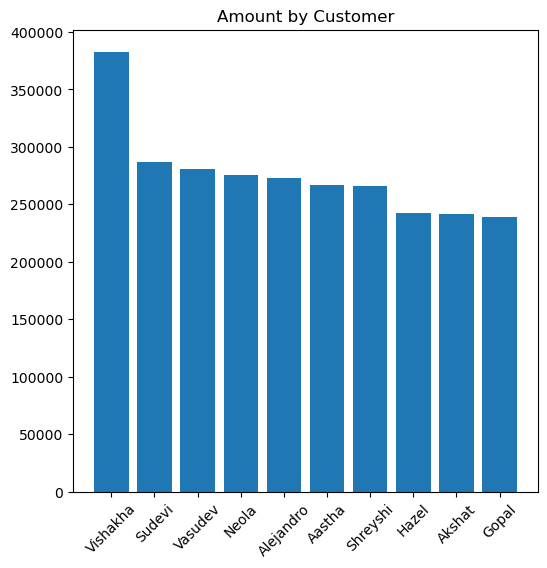

In [70]:

plt.figure(figsize=(6,6))
plt.bar(d7.index,d7.values)
plt.title('Amount by Customer')
plt.xticks(rotation=45)
plt.show()

In [76]:
#order by gender
d12=diwali.groupby('Gender')['Orders'].sum().sort_values(ascending=False)
d12

Gender
F    19554
M     8427
Name: Orders, dtype: int64

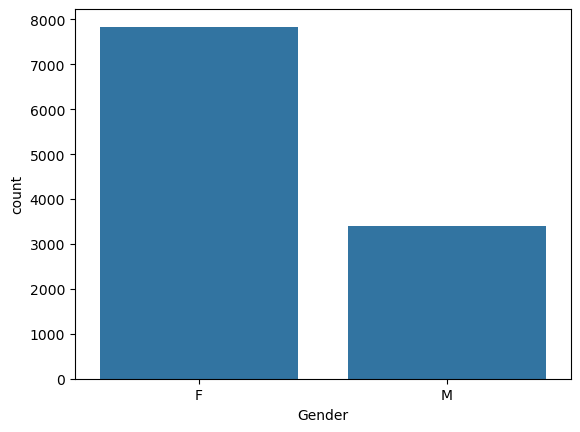

In [80]:

sns.countplot(x='Gender', data=diwali)
plt.show()

In [82]:
#order by age group
d13=diwali.groupby('Age Group')['Orders'].sum().sort_values(ascending=False)
d13

Age Group
26-35    11381
36-45     5693
18-25     4646
46-50     2379
51-55     2115
55+       1077
0-17       690
Name: Orders, dtype: int64

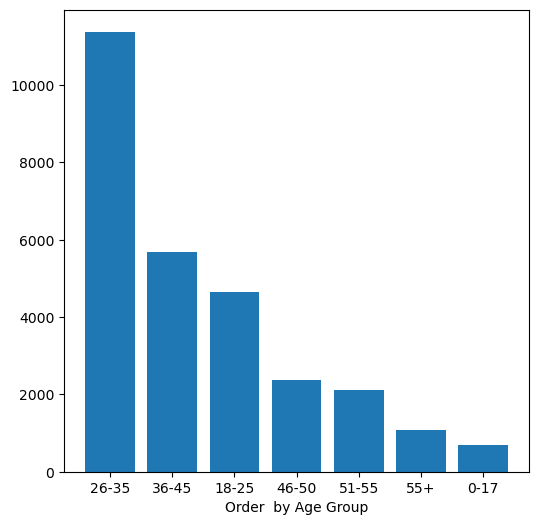

In [83]:
plt.figure(figsize=(6,6))
plt.bar(d13.index,d13.values)
plt.xlabel('Order  by Age Group')
plt.show()

In [84]:
#gender distribution
diwali['Gender'].value_counts()

Gender
F    7838
M    3405
Name: count, dtype: int64

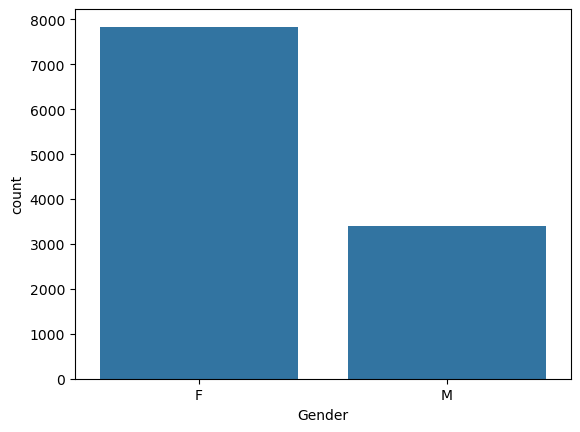

In [85]:
sns.countplot(x=diwali['Gender'],data=diwali)
plt.show()

In [90]:
d15=diwali['Marital_Status'].value_counts()
d15

Marital_Status
0    6518
1    4725
Name: count, dtype: int64

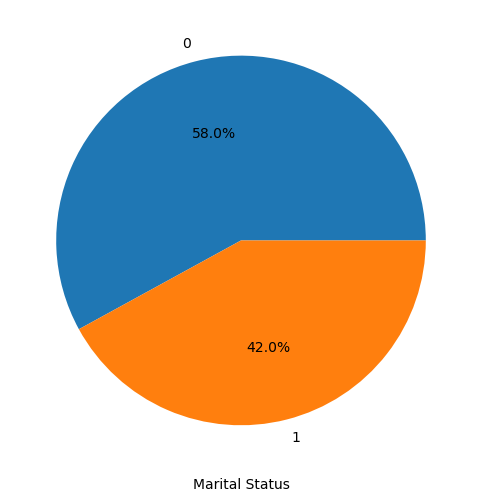

In [92]:
plt.figure(figsize=(6,6))
plt.pie(d15.values,labels=d15.index,autopct="%1.1f%%")
plt.xlabel('Marital Status')
plt.show()